(meta_analysis_experiments)=
# Multiple Experiments and Bayesian Meta-analysis

:::{post} May 2026
:tags: experimentation, meta-analysis, hierarchical models, partial pooling, replication
:category: intermediate, reference
:author: Nathaniel Forde
:::

## The replication-as-evidence problem

Eight quarterly A/B tests of the same checkout-flow redesign, run across eight markets, return eight different point estimates. Three cross the conventional significance threshold; the other five do not. The product manager asks the natural question — "did it work?" — and gets, depending on which colleague answers, two incompatible defaults: vote-counting ("four out of eight worked, so it's a wash"), or pool-everything ("the combined estimate is positive, so it works"). Both are mistakes. The vote-count discards the magnitude information in each estimate; the pool-everything pretends the markets are exchangeable in a way the evidence does not support. The honest answer requires a model that lets the markets be different, and lets that difference be part of what we are estimating.

This notebook builds that model. The hierarchical Bayesian meta-analysis treats each experiment as a noisy estimate of its own market's true effect, and treats the per-market effects as draws from a population whose mean and variance are themselves the quantities of substantive interest {cite:p}`borenstein2009meta`, {cite:p}`higgins2009meta`. The structure is the one Rubin used for the 8-schools problem in 1981 {cite:p}`rubin1981estimation`, {cite:p}`gelman2013bayesian`, transposed to product experimentation. We develop it on a continuous outcome (revenue per visitor) and then re-run it on a binary outcome (conversion). This is the third of three notebooks on the lifecycle of a Bayesian experiment; see {ref}`assurance_planning` for the planning counterpart and {ref}`sensitivity_confounding` for the interpretation counterpart. Readers wanting a deeper view of the partial-pooling vocabulary should also consult the existing PyMC notebooks on {ref}`multilevel_modeling` and {ref}`hierarchical_partial_pooling`, which we treat as predecessors rather than re-derive.

:::{admonition} Where this lands in regulatory practice
:class: note

The hierarchical model here is the borrowing mechanism a regulator now describes by name. The FDA's 2026 draft guidance on Bayesian methodology in clinical trials presents subgroup analysis through a *one-way Bayesian hierarchical model* whose subgroup estimate is "a weighted average of its raw estimated treatment effect ... and the overall estimated treatment effect" {cite:p}`fda2026bayesian`, the shrinkage picture this notebook builds. The same guidance treats hierarchical models as the main way to borrow information across related trials by assuming the group parameters are drawn from a common distribution, which is the $\theta_k \sim \mathcal{N}(\mu, \tau)$ structure below. Borrowing across studies, and the use of one trial's synthesis as the next trial's prior, is the regulatory form of the lifecycle loop these three notebooks trace.
:::

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(11)
RANDOM_SEED = 11

## Heterogeneity is not new: groups within a single study

The across-study problem looks novel, but its structure appears inside a single experiment whenever the treatment effect varies across user segments. It is worth meeting the problem on this familiar ground first, because the tool that solves it here is the tool we will carry across studies, and its classical name is the analysis of variance.

Consider one market's experiment broken out across six user segments. The redesign helps some segments more than others, and the per-segment treatment effects are themselves draws from a population. We give the section its own random generator so the across-study results later in the notebook are unaffected.

In [3]:
seg_rng = np.random.default_rng(2024)

SEG_NAMES = [
    "New / mobile",
    "New / desktop",
    "Returning / mobile",
    "Returning / desktop",
    "High-value",
    "Reactivated",
]
N_PER_SEGMENT = np.array([600, 600, 900, 900, 1400, 1400])  # visitors per segment
SEG_MU, SEG_TAU = 0.30, 0.50
BASELINE, SIGMA_OBS = 10.0, 4.0


def simulate_within_study_segments(seg_names, N_per_seg, seg_mu, seg_tau, baseline, sigma_obs, rng):
    true_effects = rng.normal(seg_mu, seg_tau, size=len(seg_names))
    rows = []
    for name, N_seg, eff in zip(seg_names, N_per_seg, true_effects):
        treat = rng.integers(0, 2, size=int(N_seg))
        revenue = baseline + eff * treat + rng.normal(0, sigma_obs, size=int(N_seg))
        rows.append(pd.DataFrame({"segment": name, "treatment": treat, "revenue": revenue}))
    return pd.concat(rows, ignore_index=True), true_effects


study_df, seg_true_effects = simulate_within_study_segments(
    SEG_NAMES, N_PER_SEGMENT, SEG_MU, SEG_TAU, BASELINE, SIGMA_OBS, seg_rng
)
study_df.head()

,segment,treatment,revenue
0,New / mobile,1,15.883319
1,New / mobile,0,14.339618
2,New / mobile,0,7.025209
3,New / mobile,0,13.596865
4,New / mobile,1,11.434889


The per-segment treatment effect is a difference of arm means; its standard error follows from the within-arm variances.

In [4]:
def segment_effect_estimates(df):
    recs = []
    for name, g in df.groupby("segment", sort=False):
        t = g.loc[g.treatment == 1, "revenue"]
        c = g.loc[g.treatment == 0, "revenue"]
        recs.append(
            {
                "segment": name,
                "d": t.mean() - c.mean(),
                "se": np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c)),
            }
        )
    return pd.DataFrame(recs)


seg_est = segment_effect_estimates(study_df)
seg_est.round(3)

,segment,d,se
0,New / mobile,0.614,0.338
1,New / desktop,0.869,0.334
2,Returning / mobile,1.243,0.251
3,Returning / desktop,-0.339,0.268
4,High-value,-0.912,0.215
5,Reactivated,0.229,0.212


The classical question "does the effect differ across segments?" is a test for the treatment-by-segment interaction, and the two-way analysis of variance answers it with an $F$-test. We compute it directly, as a comparison of nested least-squares fits, which keeps the dependency surface small and makes the variance decomposition explicit. The interaction row is the one to read.

In [5]:
def anova_two_way(df, outcome, factor, treatment):
    """Type-II two-way ANOVA via nested least-squares fits (treatment is binary)."""
    y = df[outcome].to_numpy(dtype=float)
    n = len(y)
    ones = np.ones((n, 1))
    A = pd.get_dummies(df[factor], drop_first=True).to_numpy(dtype=float)  # factor dummies
    B = pd.get_dummies(df[treatment], drop_first=True).to_numpy(dtype=float)  # treatment dummy
    AB = A * B  # interaction columns

    def fit(*blocks):
        X = np.hstack([ones, *blocks])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        return float(resid @ resid), np.linalg.matrix_rank(X)

    rss_full, k_full = fit(A, B, AB)
    rss_add, k_add = fit(A, B)
    rss_A, k_A = fit(A)
    rss_B, k_B = fit(B)
    df_resid = n - k_full
    mse = rss_full / df_resid

    terms = {
        f"C({factor})": (rss_B - rss_add, k_add - k_B),
        f"C({treatment})": (rss_A - rss_add, k_add - k_A),
        f"C({factor}):C({treatment})": (rss_add - rss_full, k_full - k_add),
    }
    rows = [
        {
            "sum_sq": ss,
            "df": float(dof),
            "F": (ss / dof) / mse,
            "PR(>F)": stats.f.sf((ss / dof) / mse, dof, df_resid),
        }
        for ss, dof in terms.values()
    ]
    rows.append({"sum_sq": rss_full, "df": float(df_resid), "F": np.nan, "PR(>F)": np.nan})
    return pd.DataFrame(rows, index=list(terms) + ["Residual"])


anova_tbl = anova_two_way(study_df, "revenue", "segment", "treatment")
anova_tbl.round(3)

,sum_sq,df,F,PR(>F)
C(segment),402.260,5.0,5.057,0.00
C(treatment),23.888,1.0,1.502,0.22
C(segment):C(treatment),828.451,5.0,10.415,0.00
Residual,92081.361,5788.0,NaN,NaN


The interaction $F$-test reports whether heterogeneity is detectable; it does not estimate how large it is. The meta-analytic siblings of the same variance decomposition do, and because they recur through the rest of the notebook it is worth stating plainly what each one measures.

:::{admonition} Three numbers for heterogeneity
:class: note

Given per-group effect estimates $\hat d_k$ with standard errors $s_k$ and inverse-variance weights $w_k = 1/s_k^2$:

- **Cochran's $Q$** measures how far the estimates spread beyond what sampling noise alone would produce. It is $Q = \sum_k w_k (\hat d_k - \bar d)^2$, where $\bar d$ is the precision-weighted mean, and it is simply the inverse-variance-weighted version of the between-groups sum of squares from ANOVA. If every group shared one true effect, $Q$ would follow a $\chi^2$ distribution with $K-1$ degrees of freedom, so a $Q$ much larger than $K-1$ is evidence of real heterogeneity.
- **$I^2 = \max\!\big(0,\, (Q - (K-1))/Q\big)$** rescales $Q$ onto the unit interval: the share of the total variation in the estimates due to genuine between-group differences rather than sampling error. $I^2 = 0$ means the spread is all noise; $I^2 = 0.9$ means most of it is real.
- **The DerSimonian–Laird estimator** is the classical, non-Bayesian way to turn $Q$ into a point estimate of the between-group variance $\tau^2$. It is a method-of-moments calculation, and once $\hat\tau^2$ is in hand the random-effects pooled mean re-weights each group by $1/(s_k^2 + \hat\tau^2)$ instead of $1/s_k^2$, so noisy groups count for less and no single precise group dominates.

See {cite:p}`borenstein2009meta` for the full treatment and {cite:p}`higgins2009meta` for the random-effects model these statistics serve.
:::

In [6]:
d = seg_est["d"].values
s = seg_est["se"].values
w = 1.0 / s**2
d_fixed = np.sum(w * d) / np.sum(w)
se_fixed = np.sqrt(1.0 / np.sum(w))
df_q = len(d) - 1
Q = np.sum(w * (d - d_fixed) ** 2)
p_Q = stats.chi2.sf(Q, df_q)
I2 = max(0.0, (Q - df_q) / Q)
C_dl = np.sum(w) - np.sum(w**2) / np.sum(w)
tau2_DL = max(0.0, (Q - df_q) / C_dl)
w_re = 1.0 / (s**2 + tau2_DL)
mu_DL = np.sum(w_re * d) / np.sum(w_re)
se_DL = np.sqrt(1.0 / np.sum(w_re))

print(f"Cochran's Q = {Q:.2f}  (df = {df_q}, p = {p_Q:.3f})")
print(f"I² = {I2:.2f}   DerSimonian–Laird between-segment SD τ = {np.sqrt(tau2_DL):.3f}")

Cochran's Q = 53.38  (df = 5, p = 0.000)
I² = 0.91   DerSimonian–Laird between-segment SD τ = 0.807


The hierarchical Bayesian model is the same random-effects analysis of variance, with one difference that matters when the number of groups is small: it returns a posterior over $\tau$ rather than a single number. With only six segments $\tau$ is weakly identified, and the DerSimonian–Laird point estimate can collapse toward zero even when real heterogeneity is present; the posterior shows that uncertainty honestly instead of hiding it in a point.

In [7]:
coords_seg = {"segment": SEG_NAMES}
with pm.Model(coords=coords_seg) as segment_model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    tau = pm.HalfNormal("tau", sigma=1.0)
    offset = pm.Normal("offset", mu=0.0, sigma=1.0, dims="segment")
    theta = pm.Deterministic("theta", mu + tau * offset, dims="segment")
    pm.Normal("d_obs", mu=theta, sigma=s, observed=d, dims="segment")
    idata_seg = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, tau, offset]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [8]:
mu_post = idata_seg.posterior["mu"]
tau_post = idata_seg.posterior["tau"]
comparison = pd.DataFrame(
    {
        "pooled effect": [d_fixed, mu_DL, float(mu_post.mean())],
        "se / sd": [se_fixed, se_DL, float(mu_post.std())],
        "between-segment τ": [0.0, np.sqrt(tau2_DL), float(tau_post.mean())],
    },
    index=[
        "Fixed-effect ANOVA (complete pooling)",
        "Random-effects ANOVA (DerSimonian–Laird)",
        "Hierarchical Bayes (partial pooling)",
    ],
)
comparison.round(3)

,pooled effect,se / sd,between-segment τ
Fixed-effect ANOVA (complete pooling),0.148,0.105,0.000
Random-effects ANOVA (DerSimonian–Laird),0.270,0.348,0.807
Hierarchical Bayes (partial pooling),0.229,0.370,0.876


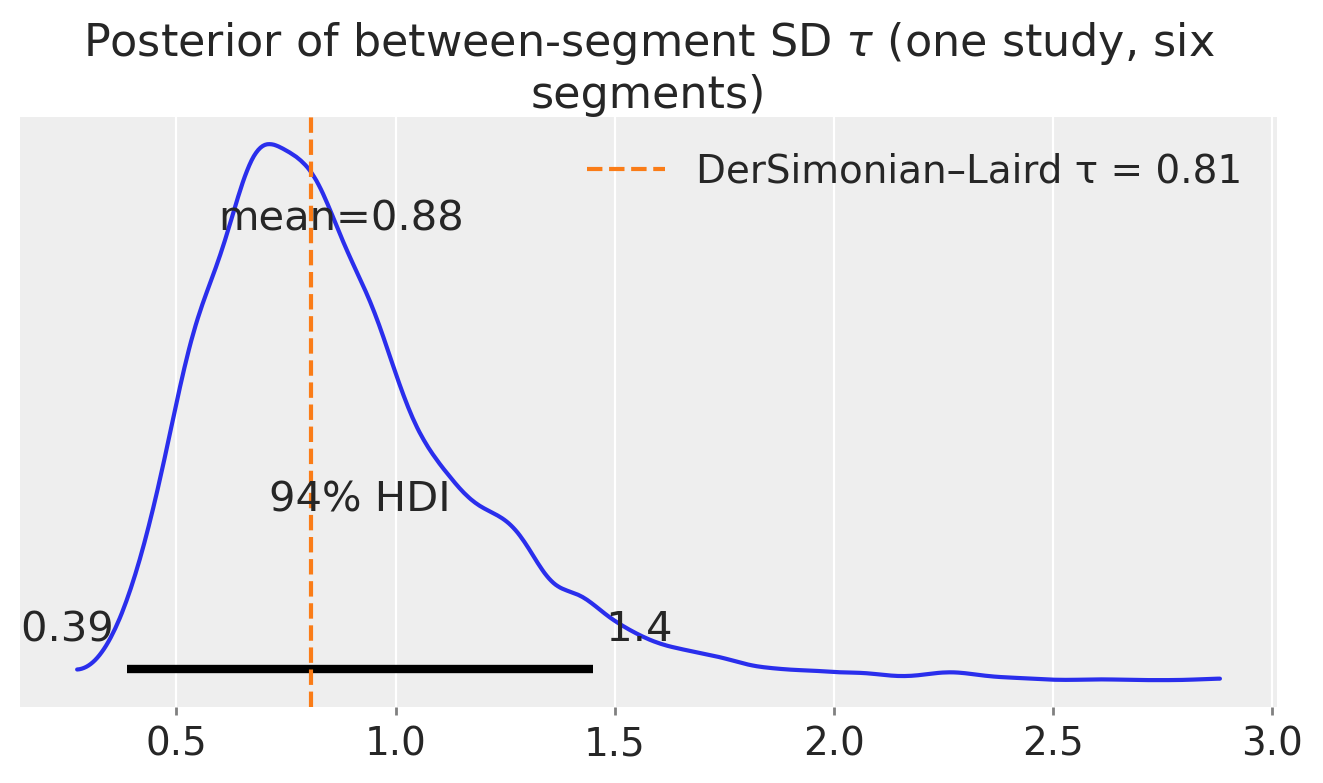

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
az.plot_posterior(idata_seg, var_names=["tau"], ax=ax)
ax.axvline(
    np.sqrt(tau2_DL),
    color="C1",
    linestyle="--",
    label=f"DerSimonian–Laird τ = {np.sqrt(tau2_DL):.2f}",
)
ax.set_title(r"Posterior of between-segment SD $\tau$ (one study, six segments)")
ax.legend();

Three estimators, three commitments about how much the segments share. The fixed-effect ANOVA assumes one common effect and pools completely; the random-effects ANOVA admits between-segment variance and estimates it by moments; the hierarchical model carries that variance as a posterior. The grouping factor throughout was the segment, and that is the only thing about to change. Replace "segment" with "study" and the model is untouched: meta-analysis is the random-effects analysis of variance with studies as the groups, and the index $k$ ranges over experiments rather than segments. The rest of this notebook makes exactly that substitution.

## The hierarchical re-framing

The model is the one we just fit, with markets in place of segments. Let $\theta_k$ be the true treatment effect in market $k$, and let $\hat d_k$ be the observed estimate from market $k$'s experiment with standard error $s_k$. The single-experiment view treats each $\hat d_k$ as the answer to its own question; vote-counting and pool-everything are degenerate cases of that view. The hierarchical view writes:

$$
\theta_k \sim \mathcal{N}(\mu, \tau), \qquad \hat d_k \mid \theta_k \sim \mathcal{N}(\theta_k, s_k),
$$

where $\mu$ is the population mean effect across markets and $\tau$ is the between-market standard deviation. The substantive story lives in both: $\mu$ tells the team what to expect *on average* from the redesign; $\tau$ tells them how variable that expectation is when the next market is queried. Neither quantity is recoverable from any single experiment. Both are recoverable from the joint.

In [10]:
K = 8
TRUE_MU = 0.30
TRUE_TAU = 0.25
SIGMA_OBS = 4.0
MARKET_NAMES = [f"Market {chr(65 + i)}" for i in range(K)]
# Per-market sample sizes vary; smaller markets have noisier estimates, which
# is the regime where partial pooling does substantively visible work.
N_PER_MARKET = np.array([200, 250, 300, 350, 400, 500, 700, 1200])


def simulate_meta_dataset_gaussian(K, N_per_market, true_mu, true_tau, sigma_obs, rng):
    theta = rng.normal(true_mu, true_tau, size=K)
    d_hat = np.zeros(K)
    s = np.zeros(K)
    for k in range(K):
        N_k = int(N_per_market[k])
        y_A = rng.normal(10.0, sigma_obs, size=N_k)
        y_B = rng.normal(10.0 + theta[k], sigma_obs, size=N_k)
        d_hat[k] = y_B.mean() - y_A.mean()
        s[k] = np.sqrt(y_A.var(ddof=1) / N_k + y_B.var(ddof=1) / N_k)
    return theta, d_hat, s


true_theta, d_hat_obs, se_obs = simulate_meta_dataset_gaussian(
    K, N_PER_MARKET, TRUE_MU, TRUE_TAU, SIGMA_OBS, rng
)
markets_df = pd.DataFrame(
    {
        "market": MARKET_NAMES,
        "N_per_arm": N_PER_MARKET,
        "true_theta": true_theta,
        "d_hat": d_hat_obs,
        "se": se_obs,
        "z_score": d_hat_obs / se_obs,
    }
)
markets_df.round(3)

,market,N_per_arm,true_theta,d_hat,se,z_score
0,Market A,200,0.309,0.475,0.385,1.232
1,Market B,250,0.640,0.900,0.371,2.427
2,Market C,300,0.606,0.728,0.330,2.208
3,Market D,350,0.172,0.888,0.300,2.961
4,Market E,400,0.226,0.596,0.293,2.031
5,Market F,500,0.168,0.494,0.244,2.029
6,Market G,700,0.442,0.663,0.215,3.081
7,Market H,1200,0.286,-0.014,0.167,-0.081


The per-market `z_score` column is what a frequentist replication exercise would consult: anything above 1.96 in absolute value counts as "significant", anything below does not. The columns disagree about how many markets "worked"; the underlying true effects disagree less. This is the gap the hierarchical model is built to close.

## No pooling, complete pooling, partial pooling

Three estimators reflect three commitments about how much the markets share. *No pooling* fits each market in isolation; the per-market estimate is $\hat d_k$. *Complete pooling* fits a single mean across all markets, treating them as draws from one distribution with no between-market variance. *Partial pooling* fits the hierarchical model above and lets the data weigh how exchangeable the markets are. The PyMC code below makes all three explicit so the shrinkage that distinguishes them becomes visible.

In [11]:
coords = {"market": MARKET_NAMES}

with pm.Model(coords=coords) as complete_model:
    mu_complete = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("d_hat", mu=mu_complete, sigma=se_obs, observed=d_hat_obs, dims="market")

with complete_model:
    idata_complete = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

with pm.Model(coords=coords) as partial_model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    tau = pm.HalfNormal("tau", sigma=1.0)
    theta_offset = pm.Normal("theta_offset", mu=0.0, sigma=1.0, dims="market")
    theta = pm.Deterministic("theta", mu + tau * theta_offset, dims="market")
    pm.Normal("d_hat", mu=theta, sigma=se_obs, observed=d_hat_obs, dims="market")

with partial_model:
    idata_partial = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, tau, theta_offset]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


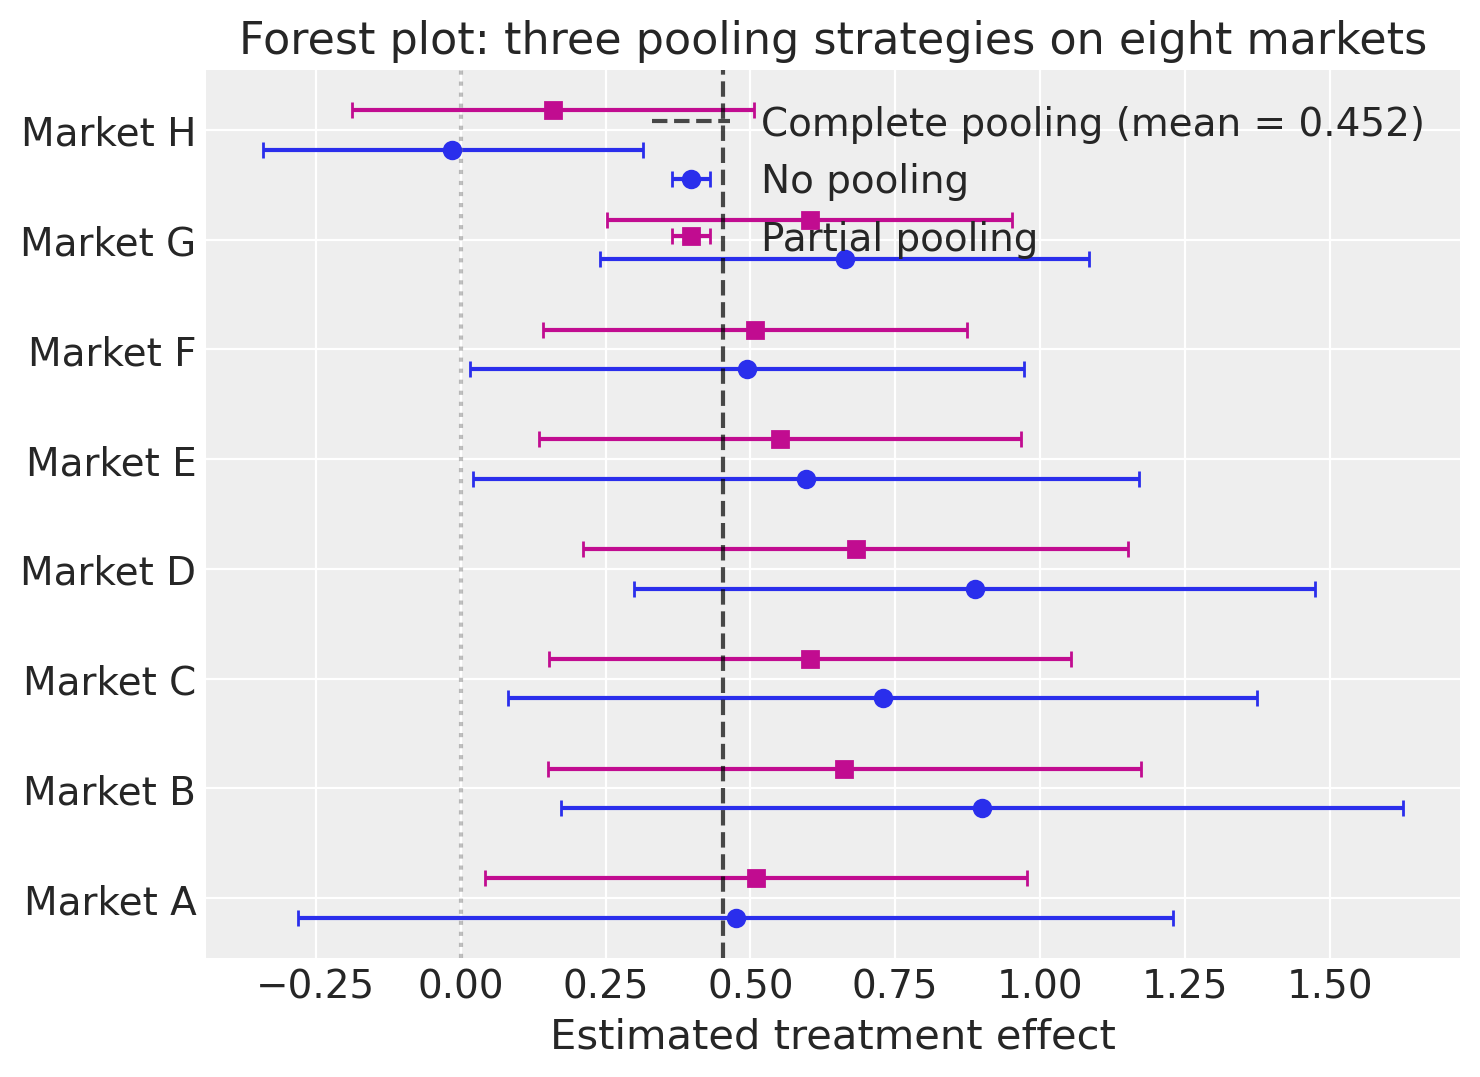

In [12]:
no_pool_mean = d_hat_obs
no_pool_se = se_obs
complete_pool_mean = idata_complete.posterior["mu"].mean().item()
complete_pool_se = idata_complete.posterior["mu"].std().item()
partial_pool_summary = az.summary(idata_partial, var_names=["theta"], kind="stats")
partial_pool_mean = partial_pool_summary["mean"].values
partial_pool_sd = partial_pool_summary["sd"].values

forest = pd.DataFrame(
    {
        "market": MARKET_NAMES,
        "no_pool_mean": no_pool_mean,
        "no_pool_lo": no_pool_mean - 1.96 * no_pool_se,
        "no_pool_hi": no_pool_mean + 1.96 * no_pool_se,
        "partial_mean": partial_pool_mean,
        "partial_lo": partial_pool_mean - 1.96 * partial_pool_sd,
        "partial_hi": partial_pool_mean + 1.96 * partial_pool_sd,
    }
).round(3)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
y_pos = np.arange(K)
ax.errorbar(
    forest["no_pool_mean"],
    y_pos - 0.18,
    xerr=[
        forest["no_pool_mean"] - forest["no_pool_lo"],
        forest["no_pool_hi"] - forest["no_pool_mean"],
    ],
    fmt="o",
    color="C0",
    label="No pooling",
    capsize=3,
)
ax.errorbar(
    forest["partial_mean"],
    y_pos + 0.18,
    xerr=[
        forest["partial_mean"] - forest["partial_lo"],
        forest["partial_hi"] - forest["partial_mean"],
    ],
    fmt="s",
    color="C3",
    label="Partial pooling",
    capsize=3,
)
ax.axvline(
    complete_pool_mean,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Complete pooling (mean = {complete_pool_mean:.3f})",
)
ax.axvline(0.0, color="grey", linestyle=":", alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(MARKET_NAMES)
ax.set_xlabel("Estimated treatment effect")
ax.set_title("Forest plot: three pooling strategies on eight markets")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0), framealpha=0.95)
plt.tight_layout();

The partial-pooling estimates are pulled toward the population mean: the canonical *shrinkage* picture {cite:p}`gelman2006multilevel`, {cite:p}`gelman2020regression`. The pull is strongest for the markets whose individual estimates are noisiest (widest no-pooling intervals) or most extreme; it is weakest for markets whose estimates are tight and central. This is the data-driven version of "borrowing strength" that vote-counting cannot do and complete-pooling does only by force.

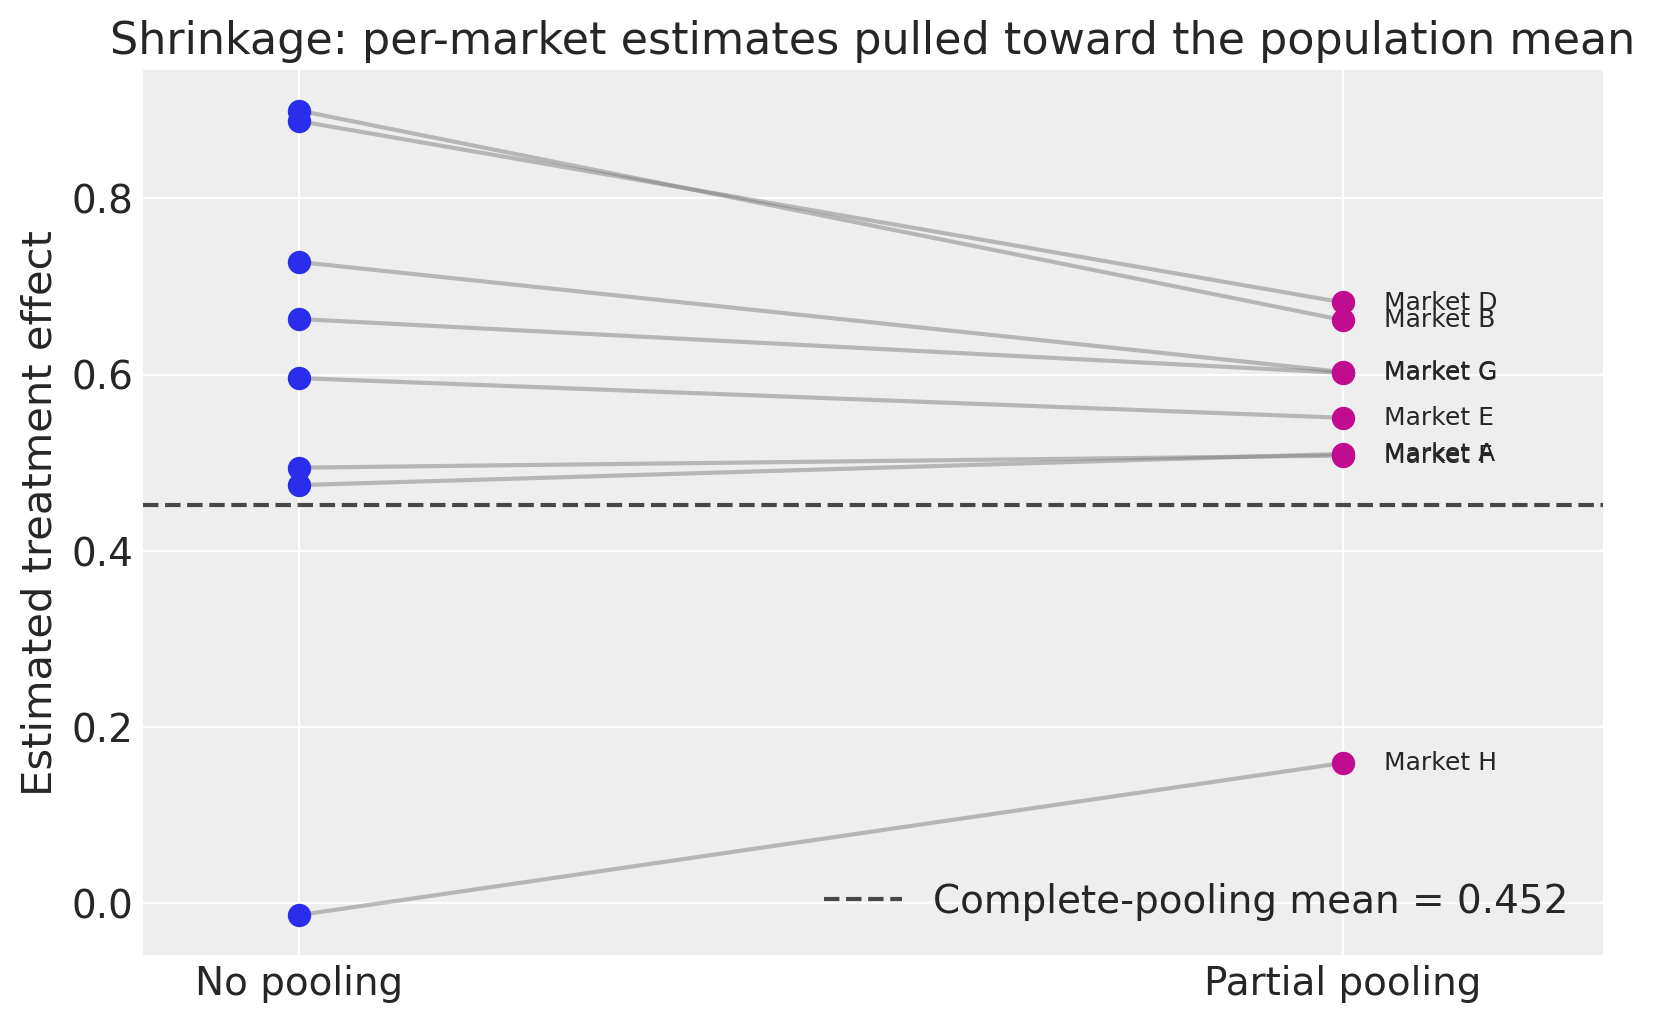

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in range(K):
    ax.plot([0, 1], [no_pool_mean[k], partial_pool_mean[k]], color="grey", alpha=0.5, zorder=1)
    ax.scatter(0, no_pool_mean[k], color="C0", zorder=3, s=55)
    ax.scatter(1, partial_pool_mean[k], color="C3", zorder=3, s=55)
    ax.text(1.04, partial_pool_mean[k], MARKET_NAMES[k], ha="left", va="center", fontsize=9)
ax.axhline(
    complete_pool_mean,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Complete-pooling mean = {complete_pool_mean:.3f}",
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No pooling", "Partial pooling"])
ax.set_xlim(-0.15, 1.25)
ax.set_ylabel("Estimated treatment effect")
ax.set_title("Shrinkage: per-market estimates pulled toward the population mean")
ax.legend(loc="lower right");

### The substance lives in $\tau$

The hierarchical model returns two population-level quantities, and the conventional reporting habit of leading with $\mu$ obscures the more important one. The posterior of $\tau$ — the between-market standard deviation of true effects — is what tells the team how transportable any single result is to a new context. A small $\tau$ means the markets are nearly exchangeable, and the experiment generalises cleanly; a large $\tau$ means the markets are heterogeneous, and the next market is a meaningfully new experiment. Reporting only $\mu$ collapses this into a point and hides the variability that the next stakeholder will live with.

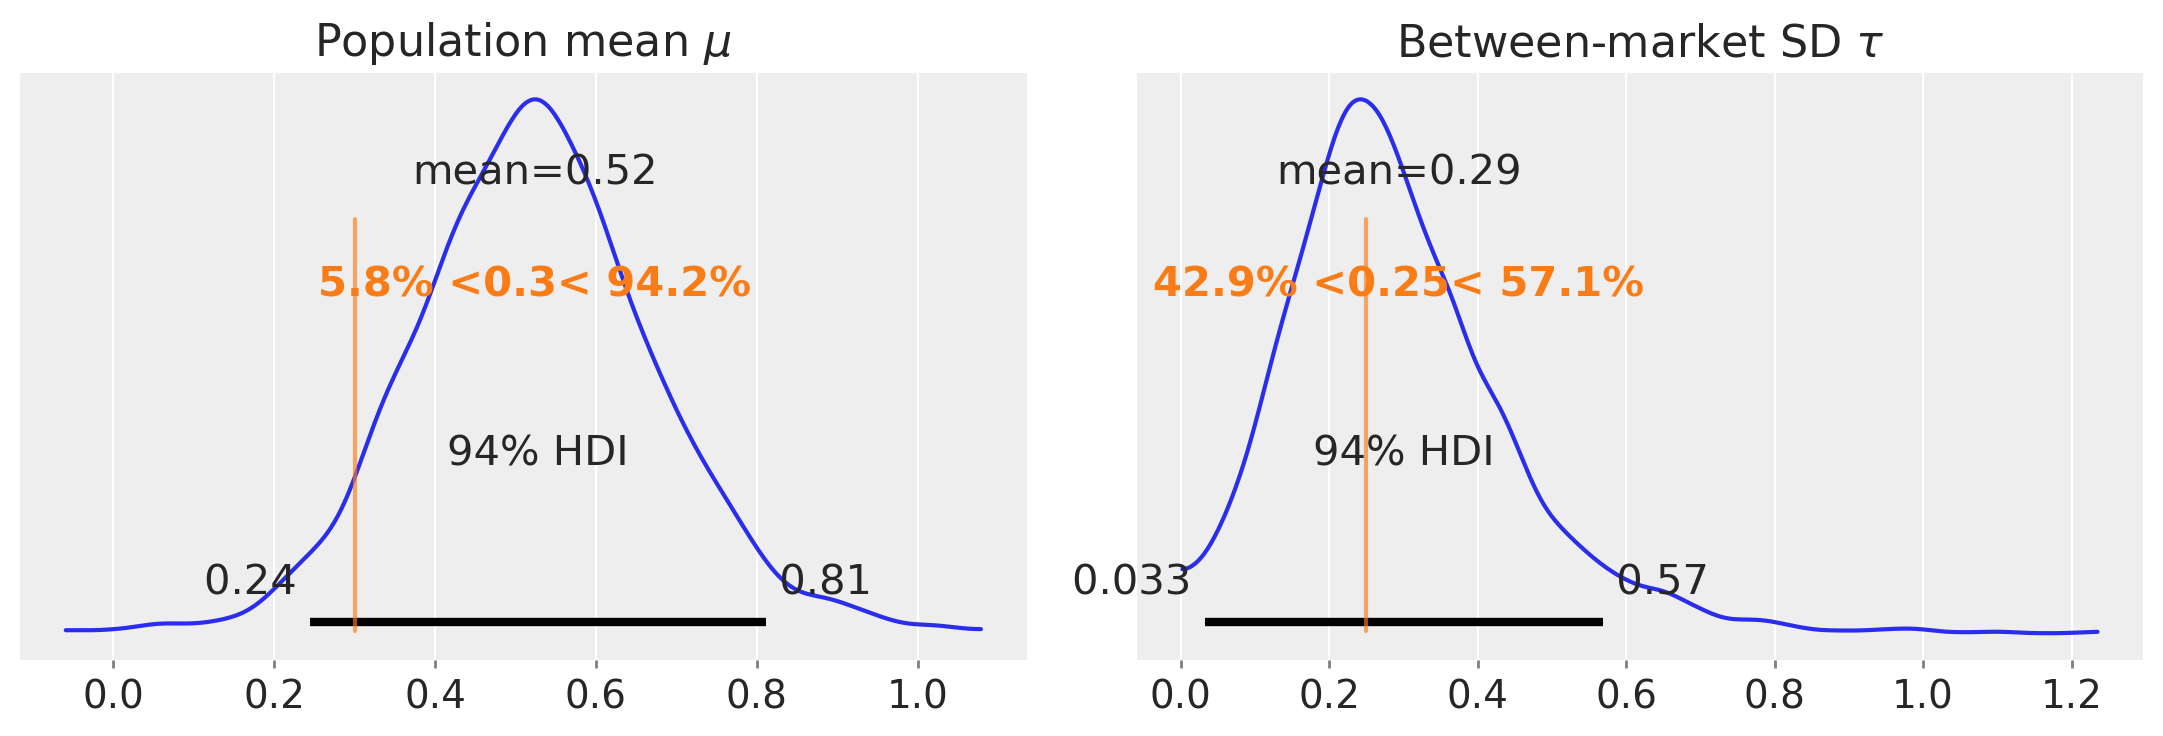

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
az.plot_posterior(idata_partial, var_names=["mu"], ref_val=TRUE_MU, ax=axes[0])
axes[0].set_title(r"Population mean $\mu$")
az.plot_posterior(idata_partial, var_names=["tau"], ref_val=TRUE_TAU, ax=axes[1])
axes[1].set_title(r"Between-market SD $\tau$")
plt.tight_layout();

The posterior of $\tau$ is concentrated well away from zero, which is itself the result of substantive interest: the eight markets disagree about the size of the treatment effect in a way the data demand be respected. The next section turns this into a prediction.

## The same machinery on a binary outcome

The conversion-rate version repeats the structure on the log-odds scale. Each market $k$ has its own baseline rate and its own treatment log-odds effect $\theta_k$; the population sits a level above ({cite:p}`carpenter2016hierarchical`).

In [15]:
TRUE_MU_LOGIT = 0.20
TRUE_TAU_LOGIT = 0.25
BASELINE_RATES = rng.beta(20, 180, size=K)


def simulate_meta_dataset_bernoulli(
    K, N_per_market, baseline_rates, true_mu_logit, true_tau_logit, rng
):
    from scipy.special import expit, logit

    theta = rng.normal(true_mu_logit, true_tau_logit, size=K)
    n_A = np.zeros(K, dtype=int)
    n_B = np.zeros(K, dtype=int)
    for k in range(K):
        p_A_k = baseline_rates[k]
        p_B_k = expit(logit(p_A_k) + theta[k])
        n_A[k] = rng.binomial(int(N_per_market[k]), p_A_k)
        n_B[k] = rng.binomial(int(N_per_market[k]), p_B_k)
    return theta, n_A, n_B


true_theta_bern, n_A_obs, n_B_obs = simulate_meta_dataset_bernoulli(
    K, N_PER_MARKET, BASELINE_RATES, TRUE_MU_LOGIT, TRUE_TAU_LOGIT, rng
)

In [16]:
with pm.Model(coords=coords) as partial_bern_model:
    mu_logit = pm.Normal("mu", mu=0.0, sigma=0.5)
    tau_logit = pm.HalfNormal("tau", sigma=0.5)
    theta_offset = pm.Normal("theta_offset", mu=0.0, sigma=1.0, dims="market")
    theta = pm.Deterministic("theta", mu_logit + tau_logit * theta_offset, dims="market")
    baseline_logit = pm.Normal("baseline_logit", mu=-2.0, sigma=1.0, dims="market")
    p_A = pm.Deterministic("p_A", pm.math.invlogit(baseline_logit), dims="market")
    p_B = pm.Deterministic("p_B", pm.math.invlogit(baseline_logit + theta), dims="market")
    pm.Binomial("obs_A", n=N_PER_MARKET, p=p_A, observed=n_A_obs, dims="market")
    pm.Binomial("obs_B", n=N_PER_MARKET, p=p_B, observed=n_B_obs, dims="market")

with partial_bern_model:
    idata_partial_bern = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, tau, theta_offset, baseline_logit]


Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


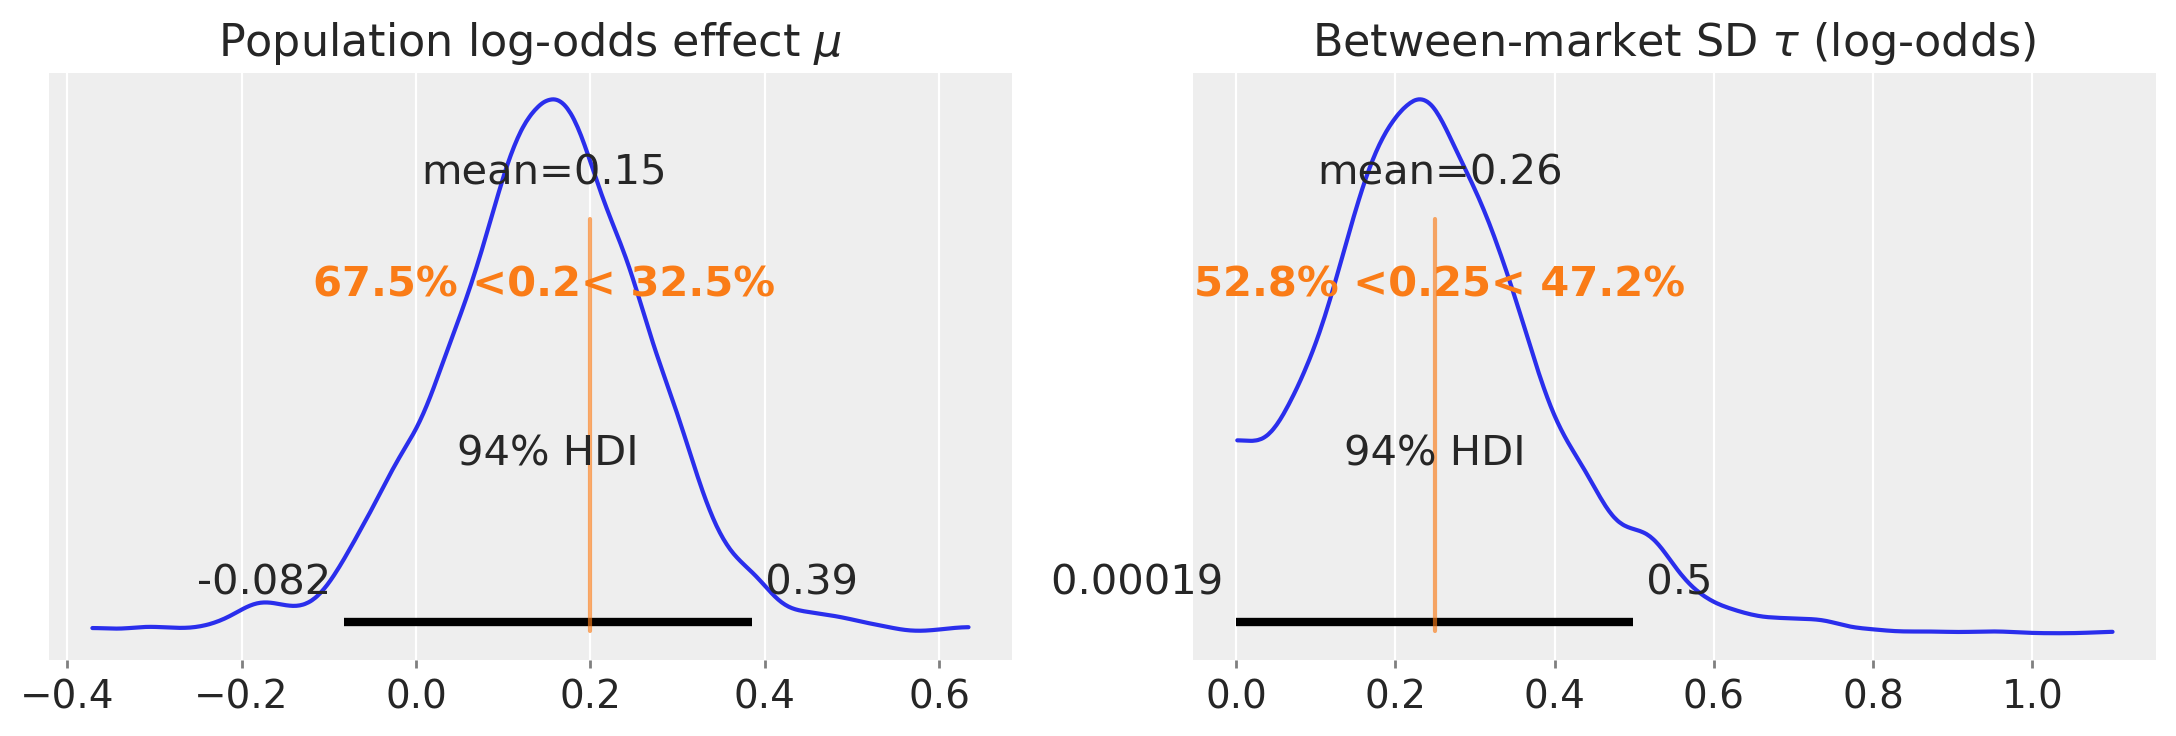

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
az.plot_posterior(idata_partial_bern, var_names=["mu"], ref_val=TRUE_MU_LOGIT, ax=axes[0])
axes[0].set_title(r"Population log-odds effect $\mu$")
az.plot_posterior(idata_partial_bern, var_names=["tau"], ref_val=TRUE_TAU_LOGIT, ax=axes[1])
axes[1].set_title(r"Between-market SD $\tau$ (log-odds)")
plt.tight_layout();

The Bernoulli picture is the Gaussian picture on a different link. The population mean log-odds effect is recovered; the between-market variance is recovered; the per-market shrinkage works as before. "Meta-analysis" is not a binary-outcome technique borrowed from medicine. It is the same Bayesian operation regardless of likelihood.

## Predicting the next experiment

The stakeholder question that occasioned this entire exercise is rarely "what was the population mean?" — it is "what will happen if we run this in Market I next quarter?". The hierarchical model answers in two posterior-predictive flavours, and the difference between them matters.

**The true-effect predictive** asks for the unknown $\theta_{\text{new}}$ of a new market drawn from the same population:

$$\theta_{\text{new}} \mid \text{data} \sim \mathcal{N}(\mu_{\text{post}}, \sqrt{\tau_{\text{post}}^2 + \sigma_{\mu, \text{post}}^2}).$$

**The observation predictive** layers experimental noise on top:

$$\hat d_{\text{new}} \mid \text{data} \sim \theta_{\text{new}} + \mathcal{N}(0, s_{\text{new}}).$$

The first is what the team should report when they say "our best estimate of the effect in a new market". The second is what they should report when they say "what we expect to see if we run the experiment again". The gap between the two is exactly the experimental-noise envelope that single-market estimates conflate with population variation.

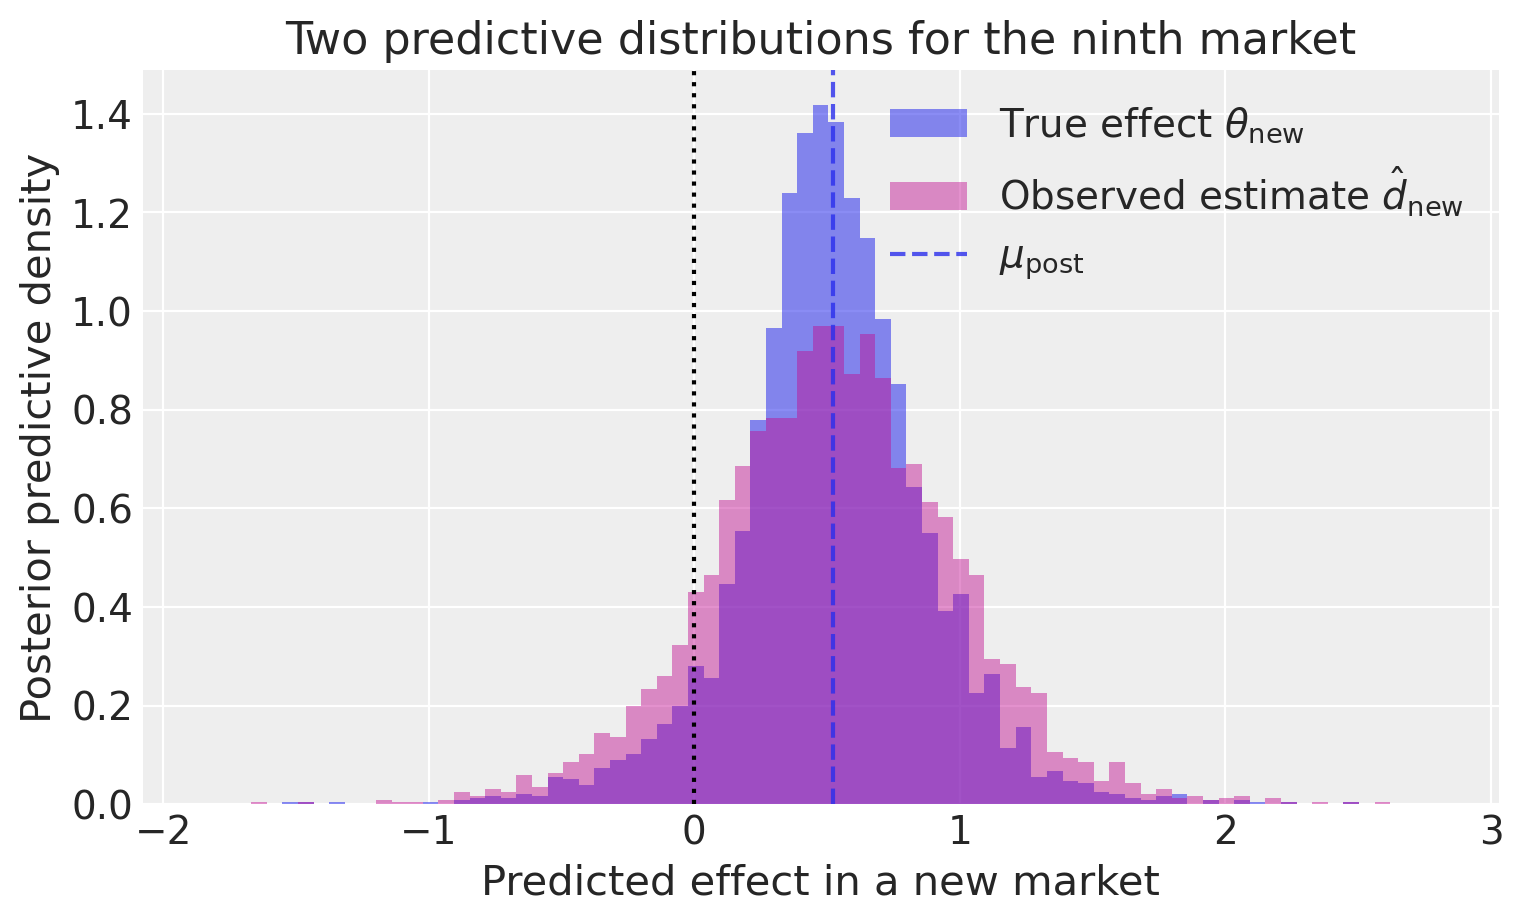

In [18]:
mu_samples = idata_partial.posterior["mu"].values.flatten()
tau_samples = idata_partial.posterior["tau"].values.flatten()
rng_pp = np.random.default_rng(RANDOM_SEED + 1)
theta_new_samples = rng_pp.normal(mu_samples, tau_samples)
s_new = np.median(se_obs)
d_hat_new_samples = theta_new_samples + rng_pp.normal(0.0, s_new, size=len(theta_new_samples))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bins = np.linspace(
    min(d_hat_new_samples.min(), theta_new_samples.min()) - 0.2,
    max(d_hat_new_samples.max(), theta_new_samples.max()) + 0.2,
    80,
)
ax.hist(
    theta_new_samples,
    bins=bins,
    alpha=0.55,
    label=r"True effect $\theta_{\text{new}}$",
    color="C0",
    density=True,
)
ax.hist(
    d_hat_new_samples,
    bins=bins,
    alpha=0.45,
    label=r"Observed estimate $\hat d_{\text{new}}$",
    color="C3",
    density=True,
)
ax.axvline(0.0, color="black", linestyle=":")
ax.axvline(mu_samples.mean(), color="C0", linestyle="--", alpha=0.8, label=r"$\mu_{\text{post}}$")
ax.set_xlabel("Predicted effect in a new market")
ax.set_ylabel("Posterior predictive density")
ax.set_title("Two predictive distributions for the ninth market")
ax.legend();

In [19]:
prob_theta_new_positive = float((theta_new_samples > 0).mean())
prob_d_hat_new_positive = float((d_hat_new_samples > 0).mean())
pd.DataFrame(
    {"posterior probability > 0": [prob_theta_new_positive, prob_d_hat_new_positive]},
    index=[r"$\theta_{\text{new}}$ (true effect)", r"$\hat d_{\text{new}}$ (observed estimate)"],
).round(3)

,posterior probability > 0
$\theta_{\text{new}}$ (true effect),0.935
$\hat d_{\text{new}}$ (observed estimate),0.886


The probability the true effect is positive in the next market is higher than the probability the next experiment will return a positive estimate. The gap is the experimental-noise tax: each individual experiment is a noisy realisation of an underlying truth, and the team will sometimes see a negative estimate even when the true effect is positive. Reporting the meta-analytic posterior on $\theta_{\text{new}}$ as the planning input for the next market — which is what {ref}`assurance_planning` will then consume as its prior — is the way to feed accumulating evidence forward without losing track of the noise.

## Replication as the data-generating process

A single experiment is overheard speech. Eight experiments are conversation. The hierarchical model is what lets us hear them as conversation rather than as eight unrelated noises, and the posterior on the population is not a number that "summarises the experiments". It is the population our experiments were drawn from, made audible by being listened to as a chorus.

This is the deeper reframing that the meta-analytic posture earns. Replication is often described as a verification protocol: a check we run on a result, after the fact, to see if it survives. The Bayesian version is more substantive than that. Replication is the data-generating process whose distribution we are trying to learn. Each new market is a draw from a population we did not have direct access to; pooling is the operation that constructs the population from the draws; the next experiment is the test that the population so constructed will continue to predict. The posterior on $\mu$ and on $\tau$ are the two halves of what we have inferred about the unobserved-but-real distribution of effects across the worlds the team operates in.

The triptych closes here, though "closes" is the wrong shape for it. The first notebook turned planning into a posterior over future posteriors; the second turned interpretation into a posterior over the bias an experiment cannot rule out; the third turned a series of experiments into a posterior over the population they sample from. Three questions, one machinery, and in each the same discipline: the quantity a conventional analysis leaves implicit, whether the believed effect, the unmeasured confounder, or the between-study variance, is made an explicit parameter with a posterior, and so becomes something a team can argue about rather than assume. The likelihood changed from Gaussian to Bernoulli each time and the picture did not. The posterior is the constant; the question changes.

And the last question feeds the first. The population this notebook inferred is the prior the planning notebook consumes: $\theta_{\text{new}} \sim \mathcal{N}(\mu, \tau)$ is precisely the kind of belief {ref}`assurance_planning` integrates over before the next experiment is run. The synthesis at the end of one experiment's lifecycle is the input to the design of the next. The lifecycle is not a line from plan to verdict but a loop, and the posterior is what travels around it.

## Authors

- Authored by [Nathaniel Forde](https://nathanielf.github.io/) in May 2026.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Thu May 28 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pytensor: 2.38.2
xarray  : 2025.12.0

pymc      : 5.28.5
matplotlib: 3.10.8
numpy     : 2.3.5
arviz     : 0.23.0
scipy     : 1.16.3
seaborn   : 0.13.2
pandas    : 2.3.3

Watermark: 2.5.0



:::{include} ../page_footer.md
:::